📖 What is EDA?

EDA (Exploratory Data Analysis) is the process of exploring and analyzing data to discover patterns, trends, relationships, and insights that help businesses make decisions.

🏢 Company Scenario

Imagine you joined IBM as a Data Analyst.

On your first day, your HR Director says:

"Ranjan, before we make any HR decisions, tell me what our workforce looks like."

So before analyzing attrition, salaries, or promotions, we first create an Executive Workforce Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Dataset

In [2]:
df = pd.read_csv("../data/featured/employee_featured.csv")

df.head()

,age,attrition_status,business_travel_frequency,daily_rate,department,distance_from_home,education_level,education_field,employee_id,environment_satisfaction,...,years_in_current_role,years_since_last_promotion,years_with_current_manager,age_group,salary_band,experience_level,promotion_due,income_per_year_experience,employee_tenure_category,attrition_risk_score
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,4,0,5,Mid Career,Medium Income,Mid-Level,No,749.12,Experienced Employee,Medium Risk
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,7,1,7,Senior Professional,Medium Income,Mid-Level,No,513.00,Experienced Employee,Low Risk
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,0,0,0,Mid Career,Low Income,Mid-Level,No,298.57,New Employee,Low Risk
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,7,3,0,Early Career,Low Income,Mid-Level,No,363.62,Experienced Employee,Low Risk
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,2,2,2,Early Career,Low Income,Mid-Level,No,578.00,New Employee,Low Risk


Dataset Verification

In [3]:
print("Shape :", df.shape)
print("\n")

print("Columns :", len(df.columns))
print("\n")

print(df.columns.tolist())

Shape : (1470, 39)


Columns : 39


['age', 'attrition_status', 'business_travel_frequency', 'daily_rate', 'department', 'distance_from_home', 'education_level', 'education_field', 'employee_id', 'environment_satisfaction', 'gender', 'hourly_rate', 'job_involvement_level', 'job_level', 'job_role', 'job_satisfaction', 'marital_status', 'monthly_income', 'monthly_rate', 'companies_worked_count', 'over_time', 'salary_hike_percent', 'performance_rating', 'relationship_satisfaction', 'stock_option_level', 'total_working_years', 'training_sessions_last_year', 'work_life_balance', 'years_at_company', 'years_in_current_role', 'years_since_last_promotion', 'years_with_current_manager', 'age_group', 'salary_band', 'experience_level', 'promotion_due', 'income_per_year_experience', 'employee_tenure_category', 'attrition_risk_score']


⭐ Phase 7.1 — Executive Workforce Overview

Imagine your CEO opens your dashboard.

What should they see first?

Not charts.

Not tables.

They should immediately know the company's workforce.

KPI 1 — Total Employees

In [4]:
total_employees = len(df)

print("Total Employees :", total_employees)

Total Employees : 1470


KPI 2 — Total Departments

In [5]:
total_departments = df["department"].nunique()

print("Departments :", total_departments)



Departments : 3


KPI 3 — Average Age

In [6]:
average_age = round(df["age"].mean(),2)

print("Average Age :", average_age)

Average Age : 36.92


KPI 4 — Average Monthly Income

In [7]:
average_salary = round(df["monthly_income"].mean(),2)

print("Average Monthly Income :", average_salary)

Average Monthly Income : 6502.93


KPI 5 — Average Experience

In [8]:
average_experience = round(df["total_working_years"].mean(),2)

print("Average Experience :", average_experience)

Average Experience : 11.28


In [9]:
df.columns

Index(['age', 'attrition_status', 'business_travel_frequency', 'daily_rate',
       'department', 'distance_from_home', 'education_level',
       'education_field', 'employee_id', 'environment_satisfaction', 'gender',
       'hourly_rate', 'job_involvement_level', 'job_level', 'job_role',
       'job_satisfaction', 'marital_status', 'monthly_income', 'monthly_rate',
       'companies_worked_count', 'over_time', 'salary_hike_percent',
       'performance_rating', 'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_sessions_last_year',
       'work_life_balance', 'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_current_manager', 'age_group',
       'salary_band', 'experience_level', 'promotion_due',
       'income_per_year_experience', 'employee_tenure_category',
       'attrition_risk_score'],
      dtype='str')

In [10]:
print(df.columns.tolist())

['age', 'attrition_status', 'business_travel_frequency', 'daily_rate', 'department', 'distance_from_home', 'education_level', 'education_field', 'employee_id', 'environment_satisfaction', 'gender', 'hourly_rate', 'job_involvement_level', 'job_level', 'job_role', 'job_satisfaction', 'marital_status', 'monthly_income', 'monthly_rate', 'companies_worked_count', 'over_time', 'salary_hike_percent', 'performance_rating', 'relationship_satisfaction', 'stock_option_level', 'total_working_years', 'training_sessions_last_year', 'work_life_balance', 'years_at_company', 'years_in_current_role', 'years_since_last_promotion', 'years_with_current_manager', 'age_group', 'salary_band', 'experience_level', 'promotion_due', 'income_per_year_experience', 'employee_tenure_category', 'attrition_risk_score']


KPI 6 — Attrition Rate

In [11]:
attrition_rate = round(
    (df["attrition_status"]=="Yes").mean()*100,
    2
)

print("Attrition Rate :", attrition_rate,"%")

Attrition Rate : 16.12 %


KPI 7 – Average Job Satisfaction

In [12]:
average_job_satisfaction = round(
    df["job_satisfaction"].mean(),
    2
)

print("Average Job Satisfaction:", average_job_satisfaction)

Average Job Satisfaction: 2.73


KPI 8 – Overtime Employees

In [13]:
overtime_employees = (df["over_time"] == "Yes").sum()

print("Employees Working Overtime:", overtime_employees)

Employees Working Overtime: 416


EDA 7.2 — Department Analysis

Now we start answering real business questions.

🏢 Business Question 1

Which department has the highest number of employees?

In [14]:
# Cell 1 — Pandas Analysis
department_count = df["department"].value_counts()

print(department_count)

department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


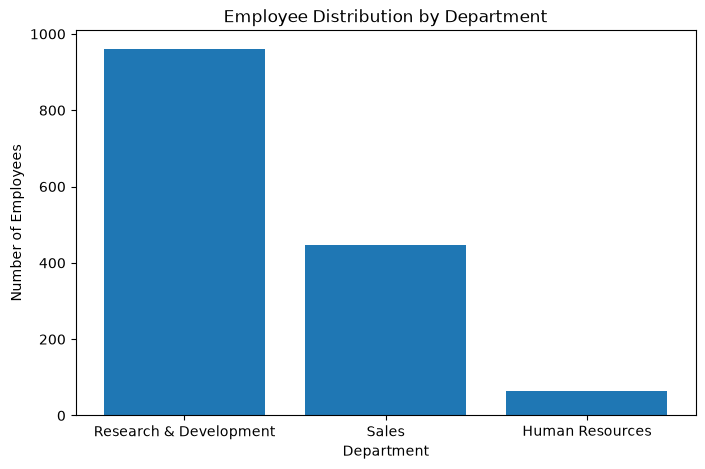

In [15]:
# Cell 2 — Matplotlib Visualization
plt.figure(figsize=(8,5))

plt.bar(
    department_count.index,
    department_count.values
)

plt.title("Employee Distribution by Department")

plt.xlabel("Department")

plt.ylabel("Number of Employees")

plt.show()

Business Insight

Research & Development has the largest workforce,
followed by Sales.

Human Resources has the smallest workforce.

Business Recommendation

Since Research & Development employs the largest
number of employees, HR should prioritize employee
engagement, retention, and workforce planning in
this department.

Even small increases in attrition here could have
a significant impact on the organization.

📊 EDA 7.3 – Department-wise Attrition Rate
📌 Business Question

Which department has the highest employee attrition rate?

🎯 Business Objective

Calculate the attrition percentage for each department to identify where employee retention efforts should be prioritized.

In [16]:
#  Step 1 – Pandas Analysis
department_total = df.groupby("department").size()
department_total

department
Human Resources            63
Research & Development    961
Sales                     446
dtype: int64

In [17]:
# Employees Left by Department
department_left = df[df["attrition_status"] == "Yes"].groupby("department").size()
department_left

department
Human Resources            12
Research & Development    133
Sales                      92
dtype: int64

In [18]:
# Calculate Attrition Rate
department_attrition_rate = (
    (department_left / department_total) * 100
).round(2)

department_attrition_rate = department_attrition_rate.sort_values(ascending=False)

department_attrition_rate

department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
dtype: float64

## 📊 Step 2 – Matplotlib Visualization


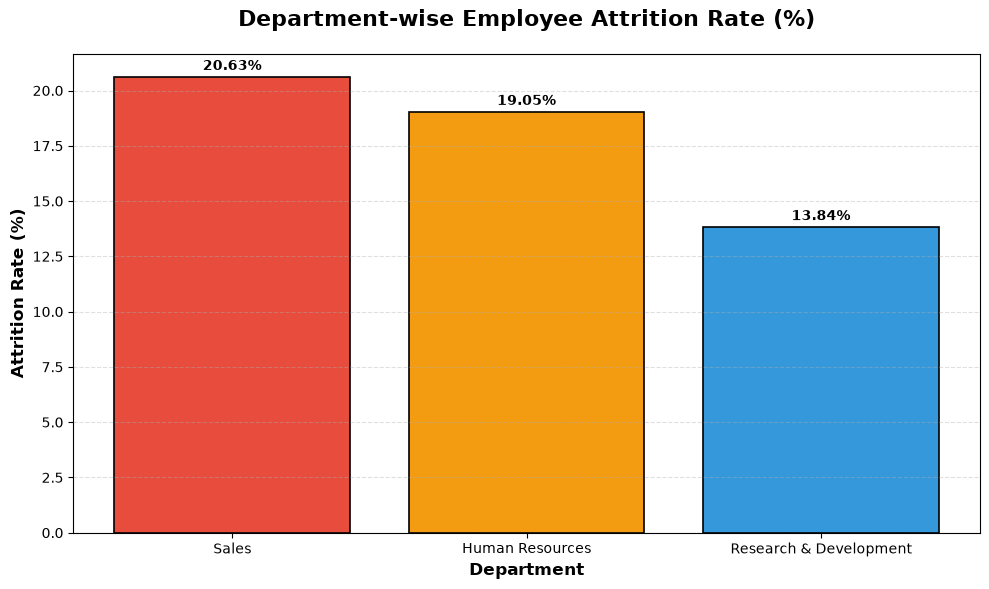

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(
    department_attrition_rate.index,
    department_attrition_rate.values,
    color=["#E74C3C", "#F39C12", "#3498DB"],
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Department-wise Employee Attrition Rate (%)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Department",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Attrition Rate (%)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

Business Insight

• Sales has the highest employee attrition rate.

• Human Resources has the second-highest attrition rate.

• Research & Development has the lowest attrition rate despite having the largest workforce.

Business Recommendation

HR should prioritize retention initiatives in departments
with the highest attrition rates.

Actions may include:

• Employee engagement programs
• Career development opportunities
• Workload assessment
• Manager feedback sessions
• Retention incentives

🎯 Interview Question

Interviewer: Why did you calculate attrition rate instead of just counting employees who left?

Answer:

"The number of employees leaving can be misleading because departments vary in size. Attrition rate normalizes the data by dividing the number of employees who left by the total number of employees in each department. This enables fair comparison across departments and supports better business decisions."

📊 EDA 7.4 – Age Group Analysis
📌 Business Question

Which age group has the highest employee attrition?

🎯 Business Objective

Identify the age groups with the highest employee turnover so HR can design targeted retention strategies.

Pandas Analysis

In [20]:
age_group_attrition = (
    df[df["attrition_status"] == "Yes"]
    .groupby("age")
    .size()
    .sort_values(ascending=False)
)

print(age_group_attrition)

age
31    18
29    18
28    14
26    12
33    12
32    11
35    10
34     9
30     9
24     7
25     6
19     6
20     6
37     6
21     6
39     6
41     6
44     6
36     6
58     5
50     5
22     5
40     5
23     4
18     4
46     4
27     3
56     3
55     3
52     3
47     3
38     2
45     2
42     2
43     2
48     2
49     2
51     2
53     2
dtype: int64


Matplotlib Visualization

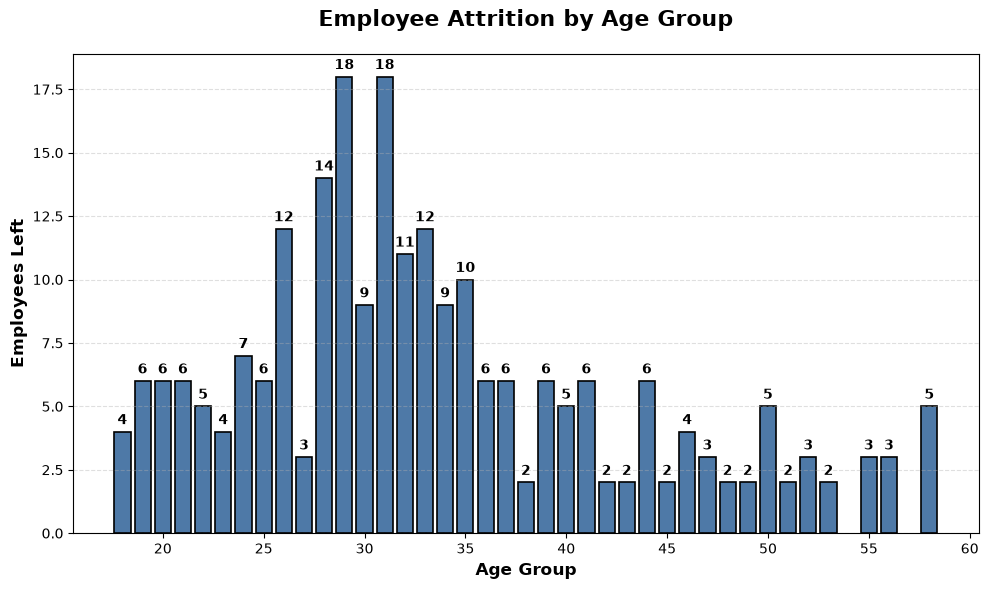

In [21]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    age_group_attrition.index,
    age_group_attrition.values,
    color="#4E79A7",
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Employee Attrition by Age Group",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Age Group",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Employees Left",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        int(bar.get_height()),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

Business Insight

• Early Career employees have the highest attrition.

• Mid Career employees show moderate attrition.

• Senior Professionals have the lowest attrition.

Business Recommendation

HR should focus on retaining employees in the early stages
of their careers through mentoring, career development,
competitive compensation, and learning opportunities.

These initiatives can reduce early employee turnover.

🎤 Interview Answer

Question: Why did you use age_group instead of age?

Answer:

"Business stakeholders understand categories such as Early Career or Mid Career more easily than individual ages. Grouping employees also makes visualizations cleaner and helps compare attrition across meaningful workforce segments."

📊 EDA 7.5 — Salary Band vs Attrition
📌 Business Question

Are lower-paid employees more likely to leave the company?

🎯 Business Objective

Analyze employee attrition across different salary bands to determine whether compensation is influencing employee retention.

📊 Why This Visualization?

We have:

Salary Band → Categorical
Attrition Status → Categorical

We want to compare two categories across multiple groups.

Best Choice

✅ Grouped Bar Chart

Why?

Because it allows direct comparison between:


Low Income

Yes     No

━━━━━━━━━━━

Medium Income

Yes     No

━━━━━━━━━━━

High Income

Yes     No

In [22]:
# Pandas Analysis
salary_attrition = pd.crosstab(
    df["salary_band"],
    df["attrition_status"]
)

print(salary_attrition)


attrition_status   No  Yes
salary_band               
High Income       256   25
Low Income        586  163
Medium Income     391   49


Matplotlib Chart

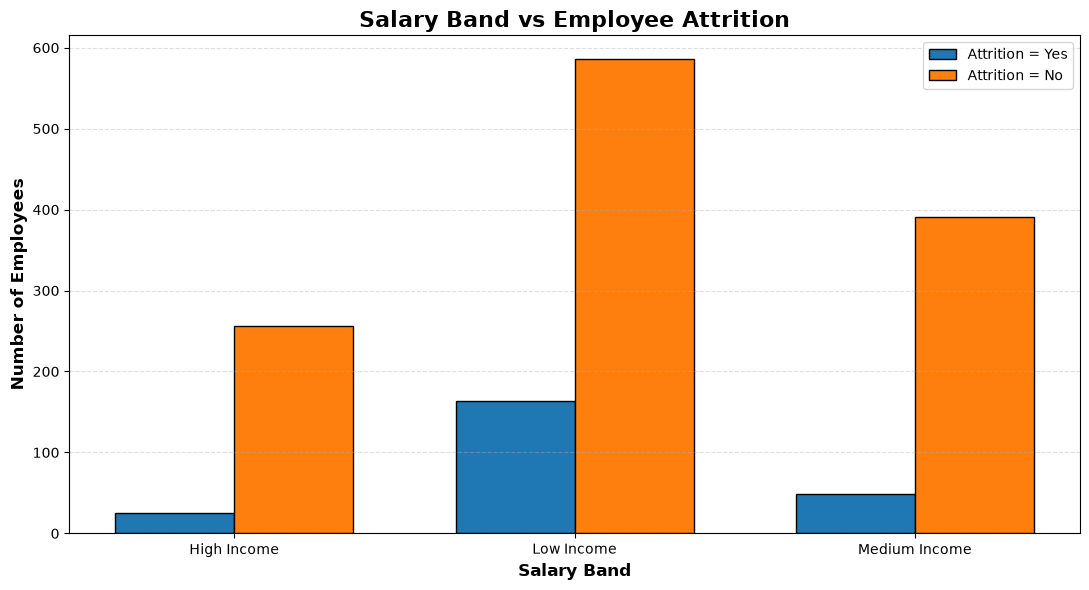

In [23]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(salary_attrition.index))

width = 0.35

plt.figure(figsize=(11,6))

plt.bar(
    x - width/2,
    salary_attrition["Yes"],
    width,
    label="Attrition = Yes",
    edgecolor="black"
)

plt.bar(
    x + width/2,
    salary_attrition["No"],
    width,
    label="Attrition = No",
    edgecolor="black"
)

plt.xticks(x, salary_attrition.index)

plt.title(
    "Salary Band vs Employee Attrition",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Salary Band",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Employees",
    fontsize=12,
    fontweight="bold"
)

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

🚀 EDA 7.5 – Workforce Compensation Analysis

Awesome! 🔥 Now our dataset is finally **production-ready**.

Current status:

* ✅ Phase 1 – Project Setup
* ✅ Phase 2 – Environment Setup
* ✅ Phase 3 – Dataset Selection
* ✅ Phase 4 – Data Understanding
* ✅ Phase 5 – Data Cleaning
* ✅ Phase 6 – Feature Engineering
* ✅ EDA 7.1 – Executive Workforce Overview
* ✅ EDA 7.2 – Department Distribution
* ✅ EDA 7.3 – Department-wise Attrition Rate
* ✅ EDA 7.4 – Age Group Analysis

---

# 🚀 EDA 7.5 – Workforce Compensation Analysis

## 📌 Business Question

> **Are lower-paid employees more likely to leave the company?**

---

## 🎯 Business Objective

Analyze employee attrition across different salary bands to determine whether compensation is a major factor influencing employee retention.

---

## 📊 Why This Visualization?

We are comparing:

* **Salary Band** (Categorical)
* **Attrition Status** (Categorical)

✅ **Best Chart:** Grouped Bar Chart

This makes it easy to compare employees who **left (Yes)** and **stayed (No)** within each salary band.



# 💡 Business Insight

*(Write this after checking your output.)*

Example:

> Employees in the **Low Income** salary band have the highest number of resignations, indicating that compensation may significantly influence employee retention.

---

# 📈 Business Recommendation

> HR should review salary structures for lower-income employees. Competitive compensation, performance incentives, and career progression opportunities can help improve retention.

---

# 🎤 Interview Question

**Q:** Why did you use a grouped bar chart?

**A:**

> "Both `salary_band` and `attrition_status` are categorical variables. A grouped bar chart enables direct comparison of employees who stayed and those who left across each salary band, making it the most suitable visualization."




In [24]:
# 🐼 Cell 1 – Pandas Analysis

salary_attrition = pd.crosstab(
    df["salary_band"],
    df["attrition_status"]
)

print(salary_attrition)


attrition_status   No  Yes
salary_band               
High Income       256   25
Low Income        586  163
Medium Income     391   49


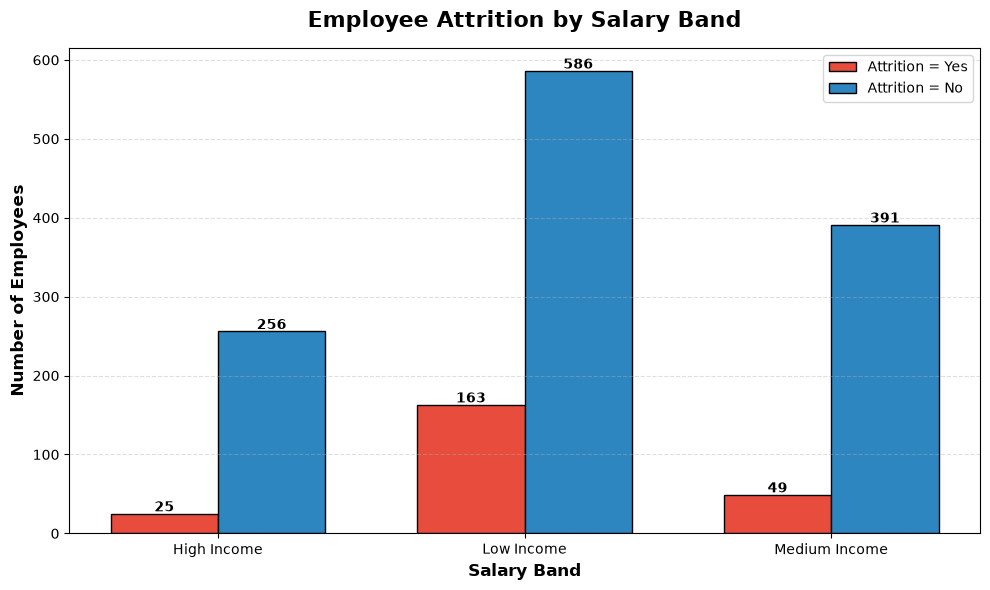

In [25]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(salary_attrition.index))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(
    x - width/2,
    salary_attrition["Yes"],
    width,
    label="Attrition = Yes",
    color="#E74C3C",
    edgecolor="black"
)

bars2 = ax.bar(
    x + width/2,
    salary_attrition["No"],
    width,
    label="Attrition = No",
    color="#2E86C1",
    edgecolor="black"
)

ax.set_title(
    "Employee Attrition by Salary Band",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Salary Band",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Employees",
    fontsize=12,
    fontweight="bold"
)

ax.set_xticks(x)
ax.set_xticklabels(salary_attrition.index)

ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.legend()

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 3,
            f"{int(height)}",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

📊 EDA 7.6 – Monthly Income Across Experience Levels
📌 Business Question

How does monthly income vary across different employee experience levels?

🎯 Business Objective

Analyze salary distribution across different experience levels to understand:

Whether salary increases with experience.
Which experience level has the highest median salary.
Whether salary ranges differ between experience groups.
Whether there are salary outliers.
📊 Why Box Plot?

A Box Plot is the best choice because it shows:

✅ Median salary
✅ Minimum salary
✅ Maximum salary
✅ Salary spread (IQR)
✅ Outliers

HR teams often use box plots for salary and compensation analysis because they reveal much more than averages.

💡 Business Insight

(Write after observing your chart.)

Example:

Monthly income generally increases with employee experience level. Senior and Expert level employees have higher median salaries and a wider salary range, while Entry Level employees have lower and more consistent salaries. A few salary outliers are present, indicating exceptional compensation for certain employees.

📈 Business Recommendation

HR should maintain structured salary progression across experience levels to ensure fair compensation and support employee retention. Salary outliers should be periodically reviewed to ensure internal pay equity and consistency.

🎤 Interview Question
Q: Why did you choose a Box Plot instead of a Bar Chart?

Answer:

"A bar chart only compares average values, which can hide important details. A box plot shows the median, spread, variability, and outliers of salaries within each experience level, making it much more suitable for compensation analysis."

In [26]:
salary_summary = df.groupby("experience_level")["monthly_income"].describe()

print(salary_summary)

                  count          mean          std     min       25%      50%  \
experience_level                                                                
Expert            207.0  15578.579710  3653.343971  5210.0  13231.00  16756.0   
Junior            316.0   2937.626582   993.406456  1009.0   2304.25   2694.5   
Mid-Level         607.0   5189.746293  2533.804477  2011.0   3116.50   4855.0   
Senior            340.0   6635.520588  3208.421677  2001.0   4414.75   5710.0   

                      75%      max  
experience_level                    
Expert            18862.0  19999.0  
Junior             3709.0   5301.0  
Mid-Level          6499.5  17444.0  
Senior             8945.0  17603.0  


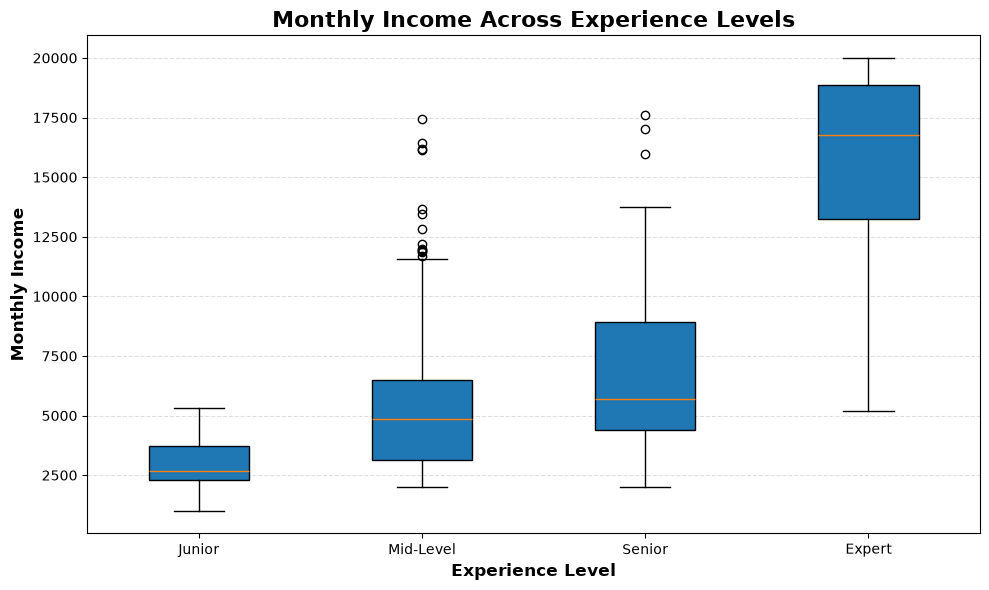

In [27]:
import matplotlib.pyplot as plt

experience_order = [
    "Junior",
    "Mid-Level",
    "Senior",
    "Expert"
]

salary_data = [
    df[df["experience_level"] == level]["monthly_income"]
    for level in experience_order
]

plt.figure(figsize=(10,6))

plt.boxplot(
    salary_data,
    tick_labels=experience_order,
    patch_artist=True
)

plt.title(
    "Monthly Income Across Experience Levels",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Experience Level",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Monthly Income",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# 📊 EDA 7.7 – Overtime Distribution Analysis

## 📌 Business Question

> **What percentage of employees work overtime?**

This is an important HR question because overtime is often linked to employee well-being, productivity, and attrition.

---

## 🎯 Business Objective

Analyze the proportion of employees who work overtime versus those who do not. This helps HR understand workforce workload and identify whether overtime is common across the organization.

---

## 📊 Why Pie Chart?

* `over_time` has only **2 categories**:

  * Yes
  * No

A **Pie Chart** is ideal for showing **part-to-whole composition** with a small number of categories.



# 💡 Business Insight

*(Write after observing the output.)*

Example:

> A majority of employees do not work overtime, while a significant percentage regularly work overtime. This suggests that workload is unevenly distributed across the workforce and may contribute to employee stress or burnout in certain roles.

---

# 📈 Business Recommendation

> HR should monitor overtime trends regularly and evaluate departments with consistently high overtime. Reducing excessive overtime through better workforce planning can improve employee well-being and reduce attrition risk.

---

# 🎤 Interview Question

### **Q: Why did you choose a Pie Chart?**

**Answer:**

> "The `over_time` variable contains only two categories (Yes and No). A pie chart effectively communicates the proportion of employees in each category, making it easy to understand the overall distribution at a glance."



In [28]:
# 🐼 Cell 1 – Pandas Analysis


overtime_count = df["over_time"].value_counts()

print(overtime_count)

over_time
No     1054
Yes     416
Name: count, dtype: int64


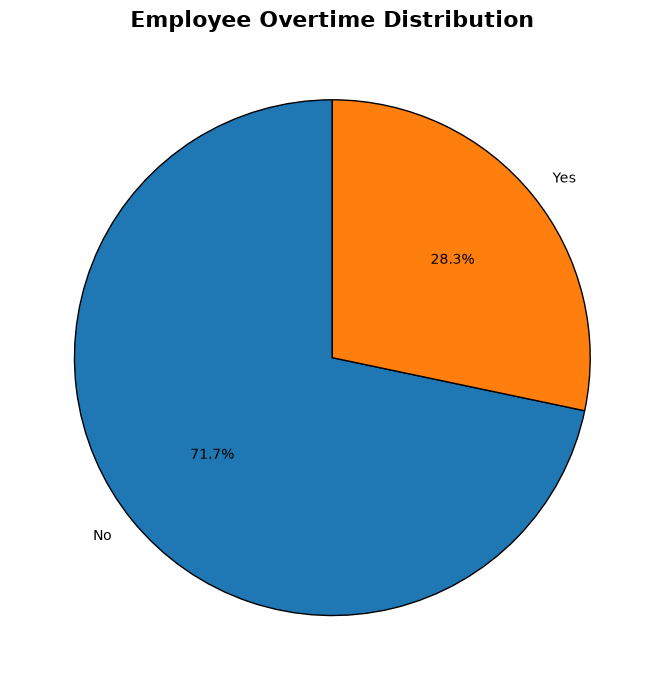

In [29]:



# 📊 Cell 2 – Matplotlib Pie Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.pie(
    overtime_count.values,
    labels=overtime_count.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black"}
)

plt.title(
    "Employee Overtime Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# 🚀 EDA 7.8 – Job Satisfaction Analysis

## 📌 Business Question

> **How satisfied are employees with their jobs?**

---

## 🎯 Business Objective

Analyze employee job satisfaction levels to identify whether the workforce is generally satisfied or whether dissatisfaction could become a risk for attrition.

---

## 📊 Why Horizontal Bar Chart?

Job satisfaction has **4 categorical levels**.

A **horizontal bar chart** is easier to read than a vertical bar chart, especially when category labels are descriptive. It also adds variety to your visualizations.



# 💡 Business Insight

*(Adjust after seeing your output.)*

Example:

> Most employees report moderate to high job satisfaction, while fewer employees fall into the lowest satisfaction category. This suggests a generally positive work environment, although employees with low satisfaction should be monitored as they may be at higher risk of leaving the organization.

---

# 📈 Business Recommendation

> HR should regularly conduct employee engagement surveys and focus on departments or teams with lower job satisfaction. Addressing workplace concerns early can improve morale, productivity, and retention.

---

# 🎤 Interview Question

**Q: Why did you choose a horizontal bar chart instead of a vertical bar chart?**

**Answer:**

> "A horizontal bar chart improves readability for categorical data and is commonly used in business dashboards. It makes category labels easier to read while allowing quick comparison of employee counts across satisfaction levels."


In [30]:

# 🐼 Cell 1 – Pandas Analysis

job_satisfaction = (
    df["job_satisfaction"]
    .value_counts()
    .sort_index()
)

print(job_satisfaction)


job_satisfaction
1    289
2    280
3    442
4    459
Name: count, dtype: int64


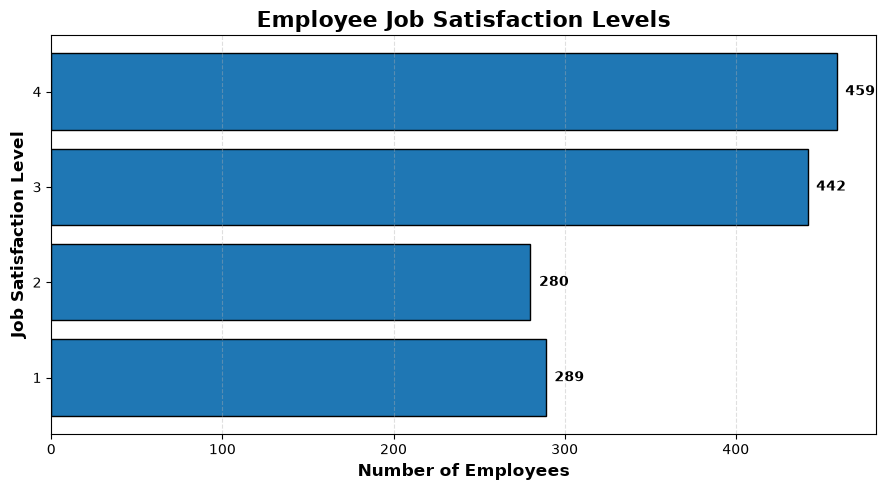

In [31]:
# 📊 Cell 2 – Matplotlib Visualization


import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

bars = plt.barh(
    job_satisfaction.index.astype(str),
    job_satisfaction.values,
    edgecolor="black"
)

plt.title(
    "Employee Job Satisfaction Levels",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Number of Employees",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Job Satisfaction Level",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# 📊 EDA 7.9 – Work-Life Balance Analysis

## 📌 Business Question

> **What is the overall work-life balance of employees?**

---

## 🎯 Business Objective

Evaluate employee work-life balance ratings to identify whether the organization is maintaining a healthy work environment or if improvements are needed.

---

## 📊 Why Lollipop Chart?

Instead of another bar chart, we'll create a **Lollipop Chart** using Matplotlib.

### Why?

* More modern and visually appealing.
* Widely used in business dashboards.
* Excellent for comparing categorical values.
* Shows that you know more than basic charts.



# 💡 Business Insight

*(Write after observing the chart.)*

Example:

> Most employees rated their work-life balance as moderate to good, indicating a generally healthy work environment. However, employees with lower ratings may require additional support through flexible work arrangements, wellness initiatives, or workload balancing.

---

# 📈 Business Recommendation

> HR should regularly monitor work-life balance through employee surveys and identify teams with lower satisfaction levels. Improving flexibility and workload management can enhance employee well-being and reduce burnout.

---

# 🎤 Interview Question

**Q:** Why did you choose a Lollipop Chart?

**Answer:**

> "A lollipop chart provides the same comparison capability as a bar chart but with a cleaner and more modern design. It is especially useful when comparing a small number of categories and improves dashboard aesthetics."


In [32]:

# 🐼 Cell 1 – Pandas Analysis

work_life = (
    df["work_life_balance"]
    .value_counts()
    .sort_index()
)

print(work_life)



work_life_balance
1     80
2    344
3    893
4    153
Name: count, dtype: int64


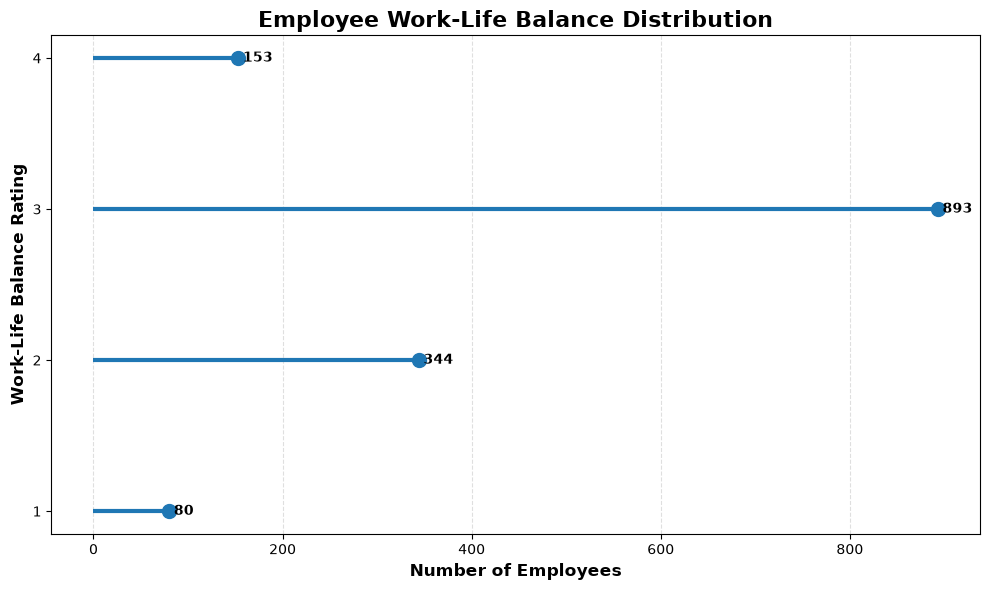

In [33]:
# 📊 Cell 2 – Matplotlib Lollipop Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hlines(
    y=work_life.index.astype(str),
    xmin=0,
    xmax=work_life.values,
    linewidth=3
)

plt.plot(
    work_life.values,
    work_life.index.astype(str),
    "o",
    markersize=10
)

# Value labels
for i, value in enumerate(work_life.values):
    plt.text(
        value + 5,
        i,
        str(value),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Employee Work-Life Balance Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Number of Employees",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Work-Life Balance Rating",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()



# 📊 EDA 7.10 – Promotion Due Analysis

## 📌 Business Question

> **How many employees may be due for a promotion?**

---

## 🎯 Business Objective

Identify employees who are due for a promotion based on the `promotion_due` feature. This helps HR plan career development and improve employee retention.

---

## 📊 Why Donut Chart?

* `promotion_due` has only two categories:

  * Yes
  * No
* A **Donut Chart** clearly shows the proportion while looking more modern than a standard pie chart.


# 💡 Business Insight

*(Write after observing your output.)*

Example:

> A noticeable proportion of employees are identified as due for promotion. This suggests that the organization should regularly review promotion cycles to maintain employee motivation and reduce the risk of losing experienced talent.

---

# 📈 Business Recommendation

> HR should prioritize performance evaluations and promotion planning for employees identified as promotion due. Transparent career progression can improve engagement, retention, and overall employee satisfaction.

---

# 🎤 Interview Question

### **Q: Why did you use a Donut Chart instead of a Pie Chart?**

**Answer:**

> "Both charts show proportions, but a donut chart provides a cleaner, more modern appearance. It is commonly used in executive dashboards because it is visually appealing while still clearly communicating the distribution."


In [34]:

# 🐼 Cell 1 – Pandas Analysis


promotion_due = df["promotion_due"].value_counts()

print(promotion_due)



promotion_due
No     1210
Yes     260
Name: count, dtype: int64


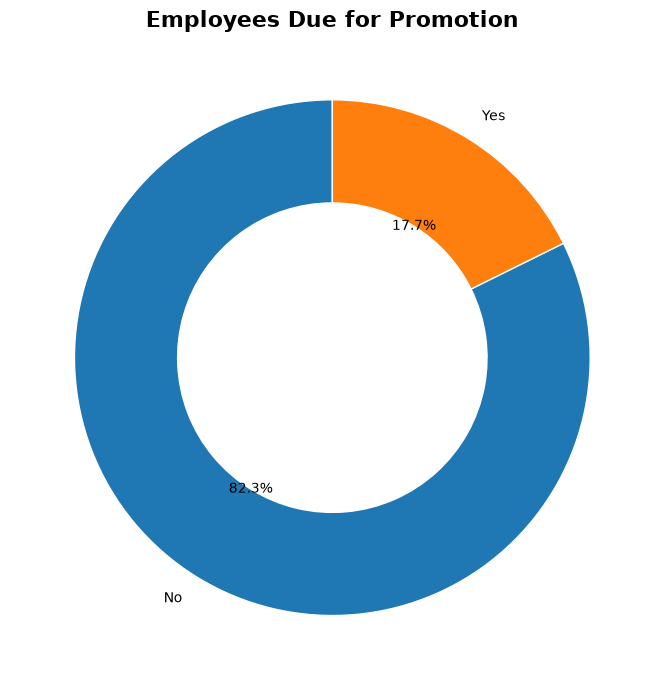

In [35]:

# 📊 Cell 2 – Matplotlib Donut Chart


import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.pie(
    promotion_due.values,
    labels=promotion_due.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={
        "width":0.4,
        "edgecolor":"white"
    }
)

plt.title(
    "Employees Due for Promotion",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

Great progress! 👏

Now let's build one of the most valuable analyses for an HR dashboard.

---

# 📊 EDA 7.11 – Attrition Risk Score Analysis

## 📌 Business Question

> **How are employees distributed across different attrition risk scores?**

---

## 🎯 Business Objective

Analyze the distribution of the engineered `attrition_risk_score` to identify how many employees fall into low-, medium-, and high-risk categories.

This is useful because the score was **created by you** during Feature Engineering.

---

## 📊 Why Histogram?

* `attrition_risk_score` is a **numeric** feature.
* A **Histogram** is the best chart to understand its distribution.

# 💡 Business Insight

*(Modify based on your output.)*

Example:

> Most employees fall into the low to moderate attrition risk range, while a smaller group has higher risk scores. These employees should be monitored closely because they may require retention strategies.

---

# 📈 Business Recommendation

> HR should proactively identify employees with higher attrition risk scores and implement retention initiatives such as career development plans, mentoring, and engagement programs.

---

# 🎤 Interview Question

### **Q: Why did you use a histogram?**

**Answer:**

> "The attrition risk score is a continuous numerical feature. A histogram is the best choice because it shows how employees are distributed across different score ranges, making it easier to identify concentration and potential high-risk groups."


In [36]:
# 🐼 Cell 1 – Pandas Analysis

print(df["attrition_risk_score"].describe())
risk_count = df["attrition_risk_score"].value_counts().sort_index()

print(risk_count)




count         1470
unique           3
top       Low Risk
freq          1005
Name: attrition_risk_score, dtype: object
attrition_risk_score
High Risk        10
Low Risk       1005
Medium Risk     455
Name: count, dtype: int64


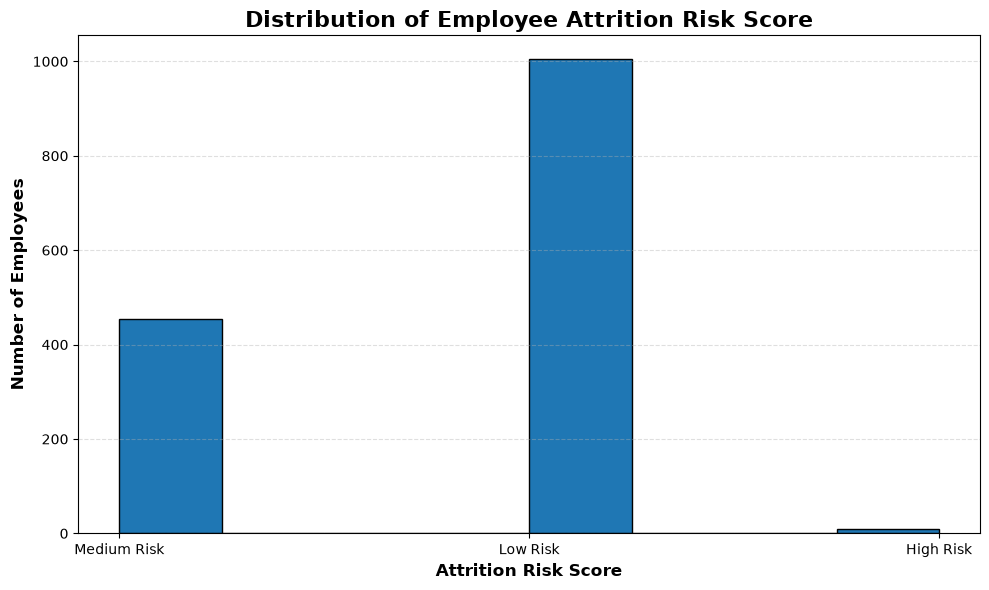

In [37]:
#  📊 Cell 2 – Matplotlib Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    df["attrition_risk_score"],
    bins=8,
    edgecolor="black"
)

plt.title(
    "Distribution of Employee Attrition Risk Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Attrition Risk Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Employees",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()




# 📊 EDA 7.12 – Which Department Has the Highest Attrition Rate?

## 📌 Business Question

> **Which department has the highest employee attrition rate?**

This is much better than just counting employees because HR cares about **attrition rate (%)**, not only the number of resignations.

---

## 🎯 Business Objective

Calculate the percentage of employees who left in each department and identify which department requires the most attention.

# 💡 Business Insight

*(Update based on your results.)*

Example:

> The Sales department has the highest attrition rate, indicating employees in this department leave more frequently than those in other departments. This suggests potential challenges related to workload, performance pressure, or career growth.

---

# 📈 Business Recommendation

> HR should investigate departments with the highest attrition rates by conducting employee feedback surveys, reviewing compensation and promotion practices, and implementing targeted retention initiatives.

---

# 🎤 Interview Question

**Q:** Why did you calculate the attrition **rate** instead of simply counting employees who left?

**Answer:**

> "Comparing only the number of employees who left can be misleading because departments have different workforce sizes. The attrition rate normalizes the data by department size, making the comparison fair and more meaningful for decision-making."

---

# ⭐ Why this analysis is valuable

This is the type of metric that appears in real HR dashboards. Instead of just showing raw counts, you're calculating a **business KPI (Attrition Rate %)**, which demonstrates stronger analytical thinking.

In [38]:

## 🐼 Cell 1 – Pandas Analysis

# Total employees in each department
department_total = df.groupby("department").size()

# Employees who left
department_attrition = (
    df[df["attrition_status"] == "Yes"]
    .groupby("department")
    .size()
)

# Calculate attrition rate
attrition_rate = (
    department_attrition / department_total * 100
).round(2)

print(attrition_rate)



department
Human Resources           19.05
Research & Development    13.84
Sales                     20.63
dtype: float64


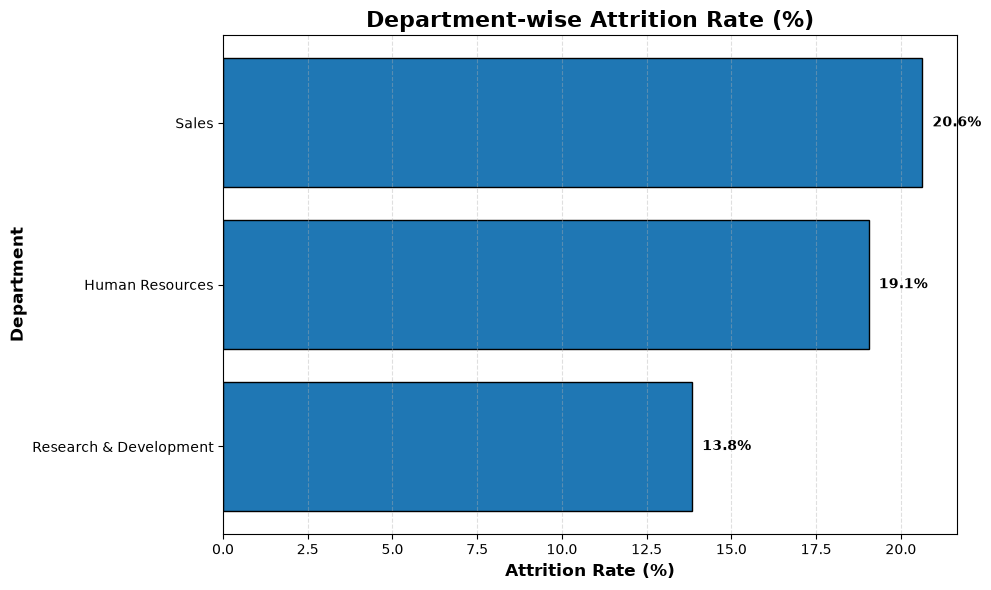

In [39]:

## 📊 Cell 2 – Matplotlib Visualization

import matplotlib.pyplot as plt

# Sort values for better visualization
attrition_rate = attrition_rate.sort_values()

plt.figure(figsize=(10,6))

bars = plt.barh(
    attrition_rate.index,
    attrition_rate.values,
    edgecolor="black"
)

plt.title(
    "Department-wise Attrition Rate (%)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Attrition Rate (%)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Department",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

# Value labels
for bar in bars:
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.1f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()




Perfect! We're now moving into **executive HR analytics**. These are the analyses that look impressive in interviews and dashboards.

---

# 📊 EDA 7.13 – Average Monthly Income by Department

## 📌 Business Question

> **Which department has the highest and lowest average monthly income?**

---

## 🎯 Business Objective

Compare the average monthly salary across departments to identify compensation differences and support salary benchmarking.

---

## 📊 Why Horizontal Bar Chart?

* We are comparing **average salary** across **departments**.
* A **horizontal bar chart** is easy to read and works well with department names.

# 💡 Business Insight

*(Modify based on your output.)*

Example:

> Research & Development has the highest average monthly income, while Human Resources has the lowest. This difference may reflect variations in technical expertise, job complexity, and organizational responsibilities.

---

# 📈 Business Recommendation

> HR should regularly benchmark salaries across departments to ensure internal equity and remain competitive with industry standards. Departments with lower compensation should be reviewed to reduce the risk of employee dissatisfaction and turnover.

---

# 🎤 Interview Question

### Q: Why did you use the **average** salary instead of the total salary?

**Answer:**

> "Total salary depends on the number of employees in each department, making comparisons unfair. The average salary provides a normalized measure that allows meaningful comparison of compensation across departments."


In [40]:
# 🐼 Cell 1 – Pandas Analysis

avg_salary = (
    df.groupby("department")["monthly_income"]
      .mean()
      .sort_values(ascending=False)
      .round(2)
)

print(avg_salary)

department
Sales                     6959.17
Human Resources           6654.51
Research & Development    6281.25
Name: monthly_income, dtype: float64


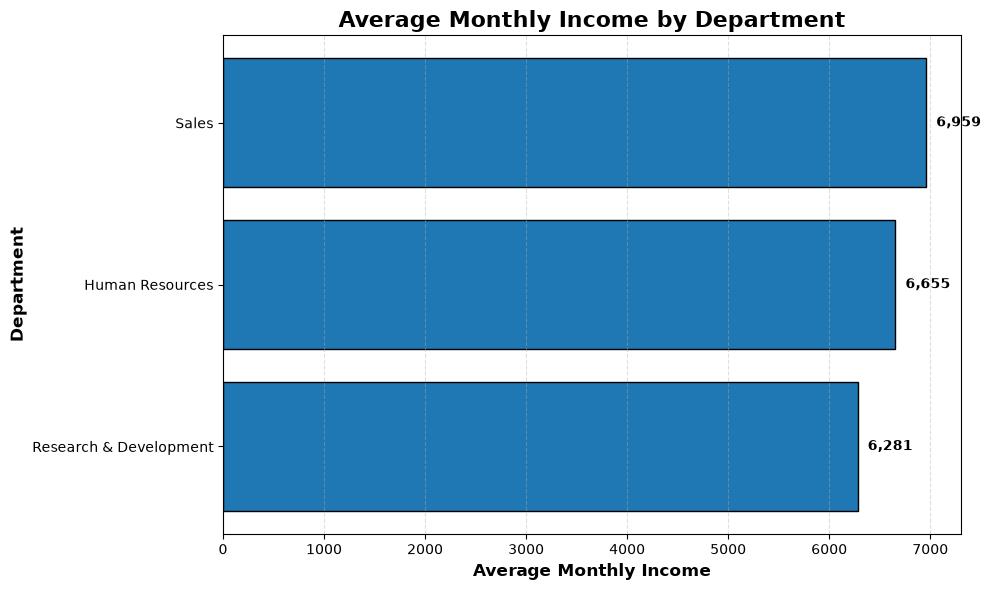

In [41]:
# 📊 Cell 2 – Matplotlib Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.barh(
    avg_salary.index,
    avg_salary.values,
    edgecolor="black"
)

plt.title(
    "Average Monthly Income by Department",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Average Monthly Income",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Department",
    fontsize=12,
    fontweight="bold"
)

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.4)

# Value Labels
for bar in bars:
    plt.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

# 📊 EDA 7.14 – Overtime vs Attrition Analysis

## 📌 Business Question

> **Does working overtime increase employee attrition?**

---

## 🎯 Business Objective

Analyze whether employees who work overtime are more likely to leave the company. This insight helps HR understand if workload contributes to employee turnover.

---

## 📊 Why Stacked Bar Chart?

We are comparing:

* `over_time` (Yes / No)
* `attrition_status` (Yes / No)

A **stacked bar chart** is ideal because it shows:

* Total employees in each overtime category.
* How that total is split between employees who stayed and those who left.

---


# 💡 Business Insight

*(Modify after observing your chart.)*

Example:

> Employees who work overtime show a noticeably higher proportion of attrition compared to employees who do not work overtime. This suggests that excessive workload may contribute to employee turnover.

---

# 📈 Business Recommendation

> HR should monitor overtime patterns and identify teams where employees consistently work extra hours. Reducing excessive overtime through better resource planning and workload balancing can improve employee well-being and retention.

---

# 🎤 Interview Question

### **Q: Why did you use a stacked bar chart instead of a grouped bar chart?**

**Answer:**

> "A stacked bar chart allows me to compare both the total number of employees working overtime and the breakdown of attrition within each group. It provides a clear view of the composition of each overtime category while saving space."



In [42]:
# 🐼 Cell 1 – Pandas Analysis


overtime_attrition = pd.crosstab(
    df["over_time"],
    df["attrition_status"]
)

print(overtime_attrition)


attrition_status   No  Yes
over_time                 
No                944  110
Yes               289  127


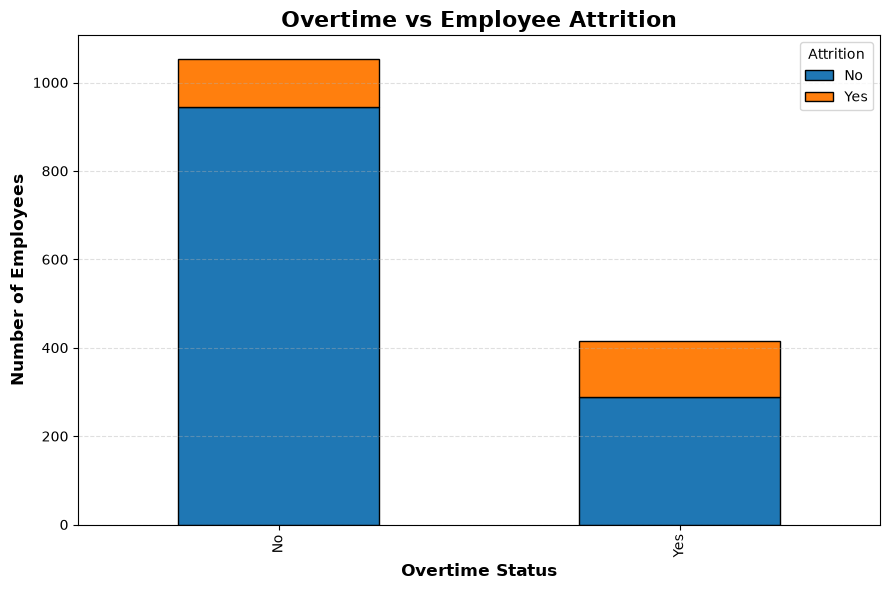

In [43]:

# 📊 Cell 2 – Matplotlib Visualization

import matplotlib.pyplot as plt

overtime_attrition.plot(
    kind="bar",
    stacked=True,
    figsize=(9,6),
    edgecolor="black"
)

plt.title(
    "Overtime vs Employee Attrition",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Overtime Status",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Employees",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(title="Attrition")

plt.tight_layout()

plt.show()



Awesome! We're almost done with the EDA phase. Now let's create one of the most valuable analyses in HR Analytics.

---

# 📊 EDA 7.15 – Job Role-wise Attrition Analysis

## 📌 Business Question

> **Which job roles experience the highest employee attrition?**

---

## 🎯 Business Objective

Identify job roles with the highest attrition to help HR focus retention efforts on critical positions.

---

## 📊 Why Horizontal Bar Chart?

* `job_role` has multiple categories with long names.
* A horizontal bar chart is much easier to read than a vertical one.
# 💡 Business Insight

*(Update after observing your chart.)*

Example:

> Sales Executives and Laboratory Technicians show the highest number of employee resignations. These roles may experience higher workload, performance pressure, or limited career growth opportunities, making them priority areas for retention initiatives.

---

# 📈 Business Recommendation

> HR should conduct role-specific retention analysis for job roles with high attrition. Measures such as targeted training, competitive compensation, career development opportunities, and workload optimization can help reduce turnover.

---

# 🎤 Interview Question

### **Q: Why did you use a horizontal bar chart?**

**Answer:**

> "Job role names are relatively long, so a horizontal bar chart improves readability. It also makes it easier to compare attrition counts across multiple categories."




In [44]:
# 🐼 Cell 1 – Pandas Analysis


job_role_attrition = (
    df[df["attrition_status"] == "Yes"]
    .groupby("job_role")
    .size()
    .sort_values(ascending=True)
)

print(job_role_attrition)


job_role
Research Director             2
Manager                       5
Healthcare Representative     9
Manufacturing Director       10
Human Resources              12
Sales Representative         33
Research Scientist           47
Sales Executive              57
Laboratory Technician        62
dtype: int64


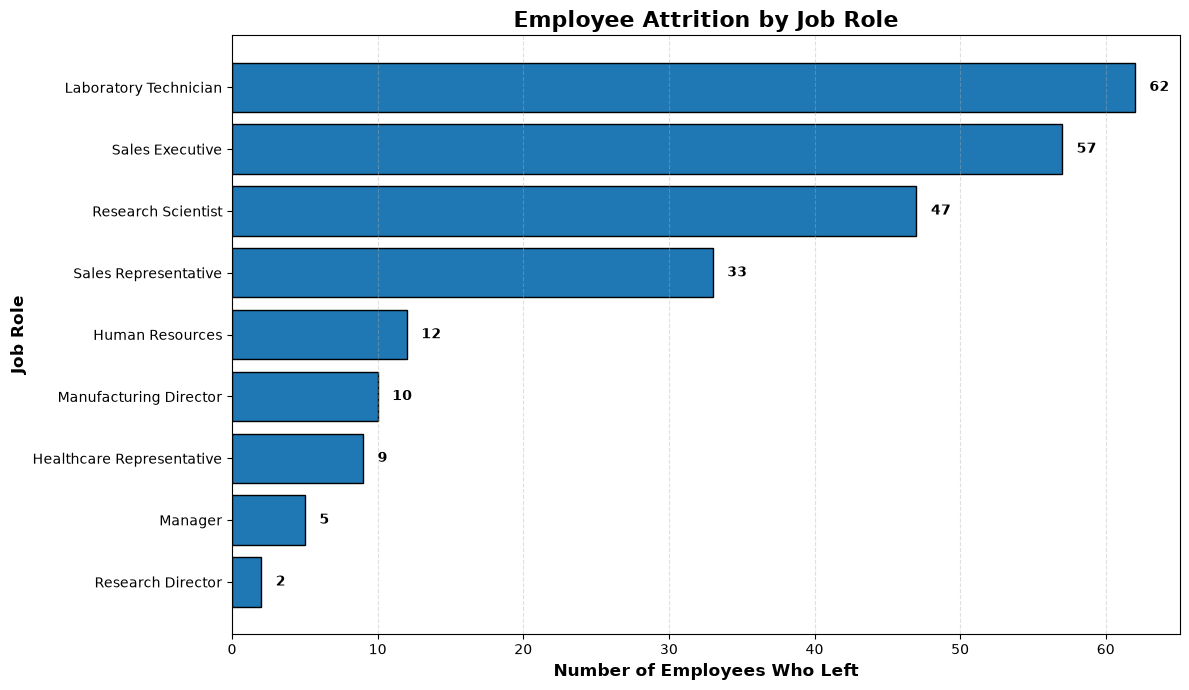

In [45]:
# 📊 Cell 2 – Matplotlib Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

bars = plt.barh(
    job_role_attrition.index,
    job_role_attrition.values,
    edgecolor="black"
)

plt.title(
    "Employee Attrition by Job Role",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Number of Employees Who Left",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Job Role",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

# Value Labels
for bar in bars:
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

# 📊 EDA 7.16 – Education Field vs Attrition

## 📌 Business Question

**Which education fields have the highest employee attrition?**

### 💡 Business Insight

Compare attrition percentage across education fields rather than employee counts.

### 📈 Recommendation

Focus retention strategies on education fields showing the highest attrition percentage.


In [46]:
### 🐼 Pandas

education_attrition = pd.crosstab(
    df["education_field"],
    df["attrition_status"],
    normalize="index"
) * 100

education_attrition = education_attrition.round(2)

print(education_attrition)


attrition_status     No    Yes
education_field               
Human Resources   74.07  25.93
Life Sciences     85.31  14.69
Marketing         77.99  22.01
Medical           86.42  13.58
Other             86.59  13.41
Technical Degree  75.76  24.24


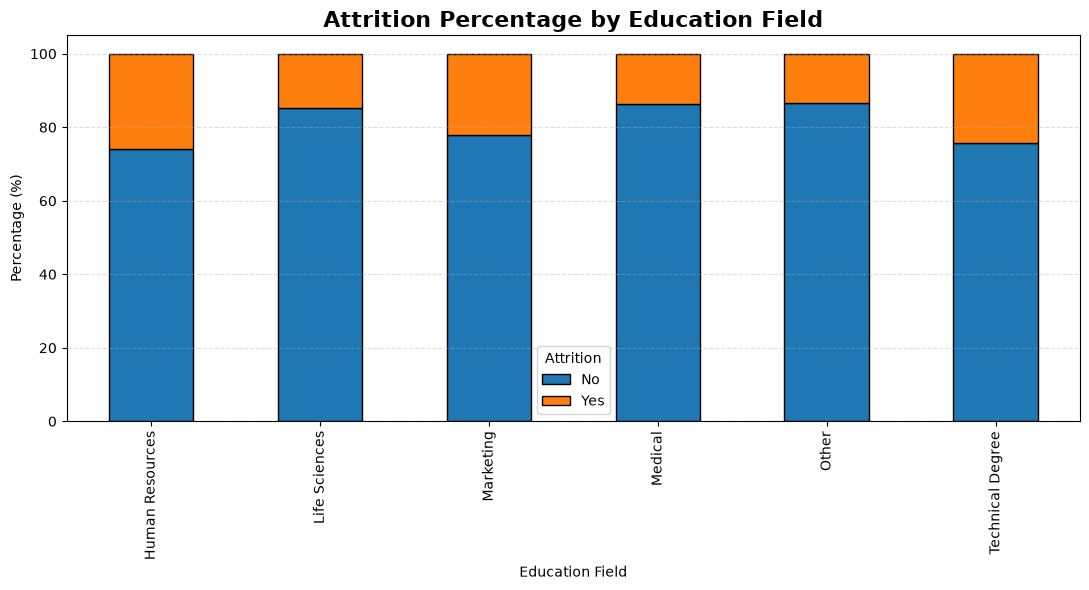

In [47]:

### 📈 Visualization


education_attrition.plot(
    kind="bar",
    stacked=True,
    figsize=(11,6),
    edgecolor="black"
)

plt.title("Attrition Percentage by Education Field",fontsize=16,fontweight="bold")
plt.xlabel("Education Field")
plt.ylabel("Percentage (%)")
plt.grid(axis="y",linestyle="--",alpha=0.4)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()


---

# 📊 EDA 7.17 – Business Travel vs Attrition

## 📌 Business Question

**Does frequent business travel increase employee attrition?**

### 💡 Business Insight

Identify whether frequent travelers resign more often.

### 📈 Recommendation

Review travel policies and employee wellness programs if frequent travelers show higher attrition.

---


In [48]:

### 🐼 Pandas

travel_attrition = pd.crosstab(
    df["business_travel_frequency"],
    df["attrition_status"]
)

print(travel_attrition)



attrition_status            No  Yes
business_travel_frequency          
Non-Travel                 138   12
Travel_Frequently          208   69
Travel_Rarely              887  156


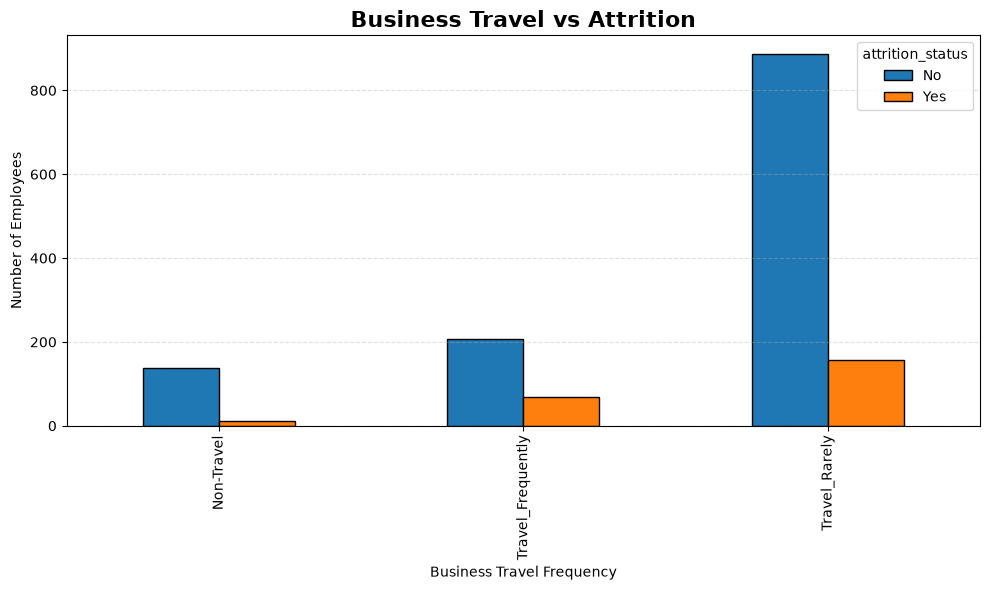

In [49]:
### 📈 Visualization


travel_attrition.plot(
    kind="bar",
    figsize=(10,6),
    edgecolor="black"
)

plt.title("Business Travel vs Attrition",fontsize=16,fontweight="bold")
plt.xlabel("Business Travel Frequency")
plt.ylabel("Number of Employees")
plt.grid(axis="y",linestyle="--",alpha=0.4)
plt.tight_layout()
plt.show()


# 📊 EDA 7.18 – Distance from Home Distribution

## 📌 Business Question

**How far do employees travel from home to work?**

### 💡 Business Insight

Observe whether most employees live close to or far from the workplace.

### 📈 Recommendation

Employees with long commutes may benefit from hybrid work, transportation support, or flexible working hours.



In [50]:
### 🐼 Pandas


print(df["distance_from_home"].describe())




count    1470.000000
mean        9.192517
std         8.106864
min         1.000000
25%         2.000000
50%         7.000000
75%        14.000000
max        29.000000
Name: distance_from_home, dtype: float64


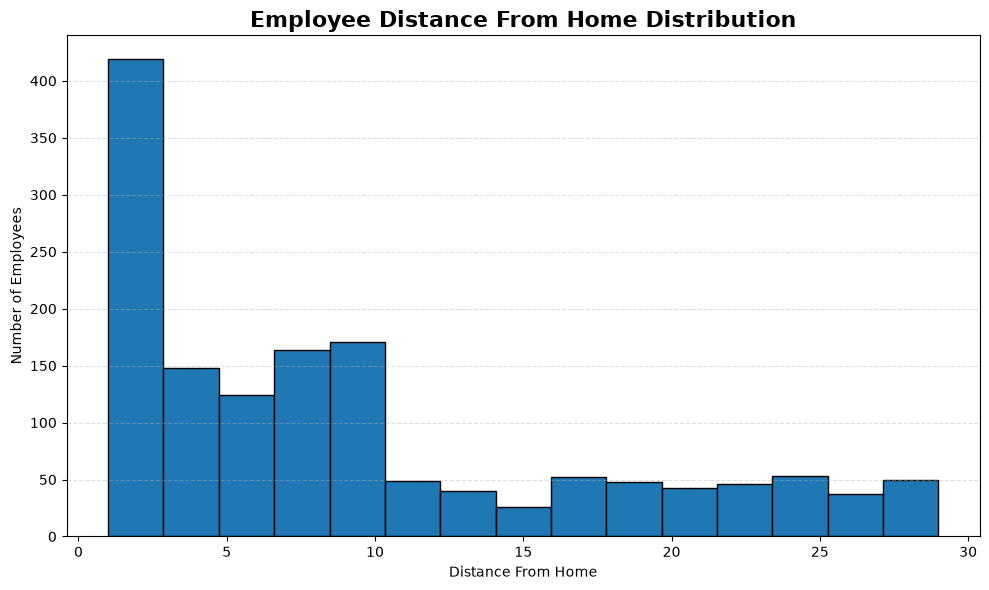

In [51]:
## 📈 Visualization

# **Histogram**

plt.figure(figsize=(10,6))

plt.hist(
    df["distance_from_home"],
    bins=15,
    edgecolor="black"
)

plt.title("Employee Distance From Home Distribution",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Distance From Home")
plt.ylabel("Number of Employees")

plt.grid(axis="y",linestyle="--",alpha=0.4)

plt.tight_layout()
plt.show()


# 📊 EDA 7.19 – Performance Rating Distribution

## 📌 Business Question

**How are employee performance ratings distributed?**

### 💡 Business Insight

Identify whether most employees receive average or high performance ratings.

### 📈 Recommendation

Review the performance evaluation process regularly to maintain fairness and identify high-potential employees.

---

In [54]:
### 🐼 Pandas

performance = (
    df["performance_rating"]
    .value_counts()
    .sort_index()
)

print(performance)



performance_rating
3    1244
4     226
Name: count, dtype: int64


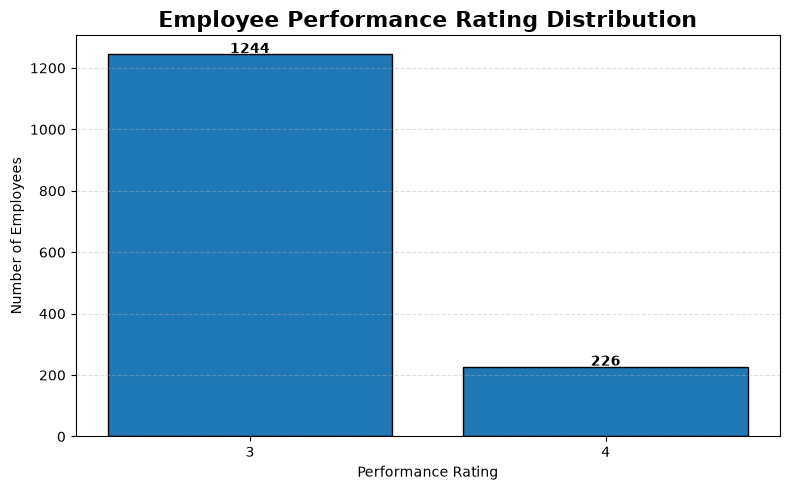

In [55]:
## 📈 Visualization


plt.figure(figsize=(8,5))

bars = plt.bar(
    performance.index.astype(str),
    performance.values,
    edgecolor="black"
)

plt.title(
    "Employee Performance Rating Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Performance Rating")
plt.ylabel("Number of Employees")

plt.grid(axis="y",linestyle="--",alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+5,
        int(bar.get_height()),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()
